# Notebook 12.1 — Financially-Aware Hyperparameter Optimization via Optuna

This notebook performs hyperparameter optimization of the validated **Adaptive Financial Transformer (AFT)** using a **financially-aligned composite objective** to align model parameters directly with trading performance.

### Key Design Choices:
1. **3-Fold Walk-Forward Cross-Validation**: Evaluate trials across 3 sequential rolling splits to handle non-stationarity.
2. **Dimensionless Composite Objective**: Normalize metrics against the verified baseline to ensure stable and portable optimization:
   $$\text{Score} = 0.40 \times \frac{\text{MAE}}{\text{MAE}_{baseline}} - 0.30 \times \frac{\text{DA}}{\text{DA}_{baseline}} - 0.30 \times \frac{\text{Sharpe}}{\text{Sharpe}_{baseline}}$$
   - $\text{MAE}_{baseline} = 0.0316$
   - $\text{DA}_{baseline} = 0.5284$
   - $\text{Sharpe}_{baseline} = 0.2423$
3. **Pruning**: Use Optuna's `MedianPruner` at the fold level based on the running average score to stop sub-optimal trials early.

In [1]:
import math
import time
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import optuna
import optuna.visualization.matplotlib as opt_vis

optuna.logging.set_verbosity(optuna.logging.WARNING)

# CPU Optimization: restrict PyTorch to 1 thread to avoid thread contention on CPU
torch.set_num_threads(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# Load master dataset and feature mapping metadata
df_master = pd.read_parquet("processed_data/master_dataset.parquet")

with open("pipeline/feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

FEATURE_GROUPS = {
    "price": ["Close","High","Low","Open","Previous_Close","Gap","Price_Change"],
    "returns": ["Daily_Return","Return","Log_Return","ROC_5","ROC_10"],
    "volatility": ["Rolling_Volatility","ATR","Historical_Volatility","Parkinson_Volatility","Garman_Klass","Rolling_STD","Rolling_Variance","Rolling_Return_STD"],
    "trend": ["EMA_9","EMA_21","EMA_50","EMA_200","EMA_12","EMA_26","MACD","Signal","MACD_Histogram"],
    "momentum": ["Momentum_5","Momentum_10","Momentum_20"],
    "volume": ["Volume","Volume_MA_5","Volume_MA_20","Relative_Volume","Volume_Change","Volume_Momentum","OBV","VWAP"],
    "candlestick": ["Body","Upper_Wick","Lower_Wick","Full_Range","Body_Ratio","Upper_Wick_Ratio","Lower_Wick_Ratio","Body_to_Wick","High_Low_Range","Open_Close_Range","True_Range"],
    "statistics": ["Rolling_Mean","Rolling_Min","Rolling_Max","Rolling_Median","Rolling_Skew","Rolling_Kurtosis","Rolling_Zscore","Rolling_Max_Return","Rolling_Min_Return"],
    "lags": ["Close_Lag_1","Return_Lag_1","Volume_Lag_1","Close_Lag_2","Return_Lag_2","Volume_Lag_2","Close_Lag_3","Return_Lag_3","Volume_Lag_3","Close_Lag_5","Return_Lag_5","Volume_Lag_5","Close_Lag_10","Return_Lag_10","Volume_Lag_10"],
    "breakout": ["Rolling_High_5","Rolling_Low_5","Rolling_High_10","Rolling_Low_10","Rolling_High_20","Rolling_Low_20","Distance_From_High_5","Distance_From_Low_5","Distance_From_High_10","Distance_From_Low_10","Distance_From_High_20","Distance_From_Low_20","Range_Position","Breakout_20","Breakdown_20"],
    "calendar": ["Day","Month","Quarter","DayOfWeek","WeekOfYear"]
}

all_features = []
for cols in FEATURE_GROUPS.values():
    all_features.extend(cols)

print(f"Master dataset rows: {len(df_master)} | Features count: {len(all_features)}")

Master dataset rows: 2721 | Features count: 95


In [3]:
print("Precomputing Top 40 features using Random Forest...")
X_rf = df_master[all_features].fillna(0)
y_rf = df_master["Future_Return"].fillna(0)

rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_rf.iloc[:int(len(X_rf)*0.7)], y_rf.iloc[:int(len(X_rf)*0.7)])

importances = pd.Series(rf.feature_importances_, index=all_features)
top_40_features = importances.sort_values(ascending=False).head(40).index.tolist()
print("Top 5 selected features:", top_40_features[:5])

Precomputing Top 40 features using Random Forest...
Top 5 selected features: ['Rolling_Skew', 'EMA_200', 'Signal', 'Parkinson_Volatility', 'MACD_Histogram']


In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MarketRegimeEncoder(nn.Module):
    def __init__(self, input_dim, feature_groups, hidden_dim=64, regime_dim=32):
        super().__init__()
        self.feature_groups = feature_groups
        self.group_embeddings = nn.ModuleDict({
            group: nn.Sequential(
                nn.Linear(len(indices), hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, regime_dim)
            )
            for group, indices in feature_groups.items()
        })
        self.temporal_score = nn.Linear(regime_dim, 1)
        self.fusion = nn.Sequential(
            nn.Linear(len(feature_groups) * regime_dim, 128),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(128, regime_dim)
        )
    def forward(self, x):
        group_vectors = []
        for group, indices in self.feature_groups.items():
            group_sequence = x[:, :, indices]
            embedding = self.group_embeddings[group](group_sequence)
            scores = self.temporal_score(embedding)
            weights = torch.softmax(scores, dim=1)
            pooled = (weights * embedding).sum(dim=1)
            group_vectors.append(pooled)
        regime = torch.cat(group_vectors, dim=1)
        return self.fusion(regime)

class AdaptiveGateNetwork(nn.Module):
    def __init__(self, regime_dim, num_groups):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(regime_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, num_groups)
        )
    def forward(self, regime):
        gates = self.network(regime)
        return torch.softmax(gates, dim=-1)

class AdaptiveFinancialContext(nn.Module):
    def __init__(self, d_head, feature_groups):
        super().__init__()
        self.feature_groups = feature_groups
        self.projections = nn.ModuleDict({
            group: nn.Linear(len(indices), d_head)
            for group, indices in feature_groups.items()
        })
    def forward(self, x, gates, use_gating=True):
        contexts = {}
        for i, (group, indices) in enumerate(self.feature_groups.items()):
            features = x[:, :, indices]
            embedding = self.projections[group](features)
            embedding = F.normalize(embedding, p=2, dim=-1)
            similarity = torch.matmul(embedding, embedding.transpose(-2, -1))
            if use_gating:
                contexts[group] = gates[:, i].view(-1, 1, 1) * similarity
            else:
                contexts[group] = (1.0 / len(self.feature_groups)) * similarity
        return contexts

class RelativeTemporalBias(nn.Module):
    def __init__(self, max_length, num_heads):
        super().__init__()
        self.max_length = max_length
        self.bias = nn.Parameter(torch.zeros(num_heads, 2 * max_length - 1))
        nn.init.trunc_normal_(self.bias, std=0.02)
    def forward(self, length):
        position = torch.arange(length, device=self.bias.device)
        relative = position[:, None] - position[None, :]
        relative += self.max_length - 1
        return self.bias[:, relative]

class ModularFinancialAttention(nn.Module):
    def __init__(self, d_head, num_heads, feature_groups, seq_len, use_financial_context=True):
        super().__init__()
        self.scale = math.sqrt(d_head)
        self.use_financial_context = use_financial_context
        self.num_groups = len(feature_groups)
        
        if use_financial_context:
            self.context = AdaptiveFinancialContext(d_head, feature_groups)
            self.group_weights = nn.Parameter(torch.ones(self.num_groups))
            self.financial_weight = nn.Parameter(torch.tensor(0.5))
            
        self.temporal_bias = RelativeTemporalBias(seq_len + 1, num_heads)
        self.temporal_weight = nn.Parameter(torch.tensor(0.5))
    def forward(self, Q, K, V, raw_features, gates, use_gating=True):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        
        if self.use_financial_context:
            contexts = self.context(raw_features, gates, use_gating)
            group_weights = torch.softmax(self.group_weights, dim=0)
            financial_bias = 0
            for i, matrix in enumerate(contexts.values()):
                financial_bias += group_weights[i] * matrix
            financial_bias = financial_bias.unsqueeze(1)
            financial_scale = torch.sigmoid(self.financial_weight)
            scores = scores + financial_scale * financial_bias
            
        temporal_bias = self.temporal_bias(Q.shape[-2]).unsqueeze(0)
        temporal_scale = torch.sigmoid(self.temporal_weight)
        scores = scores + temporal_scale * temporal_bias
        
        weights = torch.softmax(scores, dim=-1)
        return torch.matmul(weights, V), weights

class ModularMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, feature_groups, seq_len, use_financial_context=True):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.attention = ModularFinancialAttention(self.head_dim, num_heads, feature_groups, seq_len, use_financial_context)
        self.out_proj = nn.Linear(d_model, d_model)
    def forward(self, x, raw_features, gates, use_gating=True):
        B, L, _ = x.shape
        Q = self.q_proj(x).view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(x).view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(x).view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        out, weights = self.attention(Q, K, V, raw_features, gates, use_gating)
        out = out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        return self.out_proj(out), weights

class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim, dropout=0.15):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )
    def forward(self, x):
        return self.network(x)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, feature_groups, seq_len, use_financial_context=True, dropout=0.15):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attention = ModularMultiHeadAttention(d_model, num_heads, feature_groups, seq_len, use_financial_context)
        self.ffn = FeedForward(d_model, ff_dim, dropout)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, raw_features, gates, use_gating=True):
        attn_out, weights = self.attention(self.norm1(x), raw_features, gates, use_gating)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x, weights

class AdaptiveFinancialTransformer(nn.Module):
    def __init__(self, input_dim, feature_groups, seq_len, d_model=128, num_heads=8, ff_dim=256, num_layers=2,
                 use_gating=True, use_regime=True, use_financial_context=True, dropout=0.15):
        super().__init__()
        self.use_gating = use_gating
        self.use_regime = use_regime
        self.use_financial_context = use_financial_context
        self.feature_groups = feature_groups
        
        self.embedding = nn.Linear(input_dim, d_model)
        self.position = PositionalEncoding(d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.dropout = nn.Dropout(dropout)
        
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, ff_dim, feature_groups, seq_len, use_financial_context, dropout)
            for _ in range(num_layers)
        ])
        
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        if use_regime:
            self.market_encoder = MarketRegimeEncoder(input_dim, feature_groups)
            if use_gating:
                self.gate_network = AdaptiveGateNetwork(32, len(feature_groups))
    def forward(self, x):
        raw_features = x
        B, L, _ = x.shape
        
        # Gate setup
        if self.use_regime:
            regime = self.market_encoder(raw_features)
            if self.use_gating:
                gates = self.gate_network(regime)
            else:
                gates = torch.ones(B, len(self.feature_groups), device=x.device) / len(self.feature_groups)
        else:
            gates = torch.ones(B, len(self.feature_groups), device=x.device) / len(self.feature_groups)
            regime = None
            
        x = self.embedding(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        
        cls_raw = torch.zeros(B, 1, raw_features.size(-1), device=x.device)
        raw_features = torch.cat([cls_raw, raw_features], dim=1)
        
        x = self.position(x)
        x = self.dropout(x)
        
        attention_maps = []
        for layer in self.layers:
            x, weights = layer(x, raw_features, gates, self.use_gating)
            attention_maps.append(weights)
            
        prediction = self.head(x[:, 0]).squeeze(-1)
        return prediction, attention_maps, regime, gates

In [5]:
def create_sequences(X_scaled, y_series, seq_len):
    X_seq = []
    y_seq = []
    for i in range(len(X_scaled) - seq_len):
        X_seq.append(X_scaled[i : i + seq_len])
        # Forecast y at time step i + seq_len (exactly aligned to baseline validation)
        y_seq.append(y_series.iloc[i + seq_len])
    return torch.tensor(np.array(X_seq), dtype=torch.float32), torch.tensor(np.array(y_seq), dtype=torch.float32)

def evaluate_model(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        preds, _, _, _ = model(X_tensor.to(DEVICE))
        preds = preds.cpu().numpy()
    y_true = y_tensor.numpy()
    
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)
    
    # Directional Accuracy
    dir_accuracy = np.mean(np.sign(y_true) == np.sign(preds))
    return mae, r2, dir_accuracy

In [6]:
def train_model_fold(X_tr, y_tr, X_va, y_va, params, feature_groups):
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_va, y_va), batch_size=64, shuffle=False)
    
    model = AdaptiveFinancialTransformer(
        input_dim=X_tr.shape[2], feature_groups=feature_groups, seq_len=X_tr.shape[1],
        d_model=params["d_model"], num_heads=params["num_heads"], 
        ff_dim=params["ff_dim"], num_layers=params["num_layers"], dropout=params["dropout"]
    ).to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["wd"], betas=(0.9, 0.95))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    
    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(25):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            preds, _, _, _ = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                preds, _, _, _ = model(X_batch)
                val_loss += criterion(preds, y_batch).item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= 5:
            break
            
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})
    return model

In [7]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 5e-3, log=True)
    wd = trial.suggest_float("wd", 1e-6, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    seq_len = trial.suggest_categorical("seq_len", [20, 40, 60, 80])
    d_model = trial.suggest_categorical("d_model", [64, 96, 128, 160, 192])
    ff_multiplier = trial.suggest_categorical("ff_multiplier", [2, 4])
    ff_dim = ff_multiplier * d_model
    num_heads = trial.suggest_categorical("num_heads", [4, 8])
    num_layers = trial.suggest_categorical("num_layers", [2, 3])
    use_top40 = trial.suggest_categorical("use_top40", [False, True])
    
    params = {
        "lr": lr, "wd": wd, "dropout": dropout, "seq_len": seq_len,
        "d_model": d_model, "ff_dim": ff_dim, "num_heads": num_heads, 
        "num_layers": num_layers, "use_top40": use_top40
    }
    
    if use_top40:
        features = top_40_features
    else:
        features = all_features
        
    group_indices = {
        group: [features.index(col) for col in cols if col in features]
        for group, cols in FEATURE_GROUPS.items()
    }
    group_indices = {g: idx for g, idx in group_indices.items() if len(idx) > 0}
    
    total_size = len(df_master)
    fold_size = int(total_size * 0.25)
    
    maes = []
    das = []
    sharpes = []
    
    for fold in range(3):
        train_start = fold * fold_size
        train_end = train_start + int(fold_size * 0.7)
        val_end = train_start + int(fold_size * 0.85)
        
        df_train = df_master.iloc[train_start:train_end]
        df_val = df_master.iloc[train_end:val_end]
        
        scaler = StandardScaler()
        X_tr_raw = scaler.fit_transform(df_train[features].fillna(0))
        X_va_raw = scaler.transform(df_val[features].fillna(0))
        
        y_train_raw = df_train["Future_Return"].fillna(0)
        y_val_raw = df_val["Future_Return"].fillna(0)
        
        X_tr, y_tr = create_sequences(X_tr_raw, y_train_raw, seq_len)
        X_va, y_va = create_sequences(X_va_raw, y_val_raw, seq_len)
        
        if len(X_tr) == 0 or len(X_va) == 0:
            raise ValueError(f"Empty split created: len(X_tr)={len(X_tr)}, len(X_va)={len(X_va)} for seq_len={seq_len}")
            
        try:
            model = train_model_fold(X_tr, y_tr, X_va, y_va, params, group_indices)
            
            # Predict and evaluate
            model.eval()
            with torch.no_grad():
                preds, _, _, _ = model(X_va.to(DEVICE))
                preds = preds.cpu().numpy()
            y_true = y_va.numpy()
            
            mae = mean_absolute_error(y_true, preds)
            dir_acc = np.mean(np.sign(y_true) == np.sign(preds))
            
            # Sharpe calculation on validation returns
            pred_dir = np.sign(preds)
            pred_dir[np.abs(preds) < 1e-6] = 0.0
            strategy_returns = pred_dir * y_true
            mean_ret = np.mean(strategy_returns)
            std_ret = np.std(strategy_returns) + 1e-9
            fold_sharpe = (mean_ret / std_ret) * np.sqrt(252 / 5)
            
            maes.append(mae)
            das.append(dir_acc)
            sharpes.append(fold_sharpe)
        except Exception as e:
            import traceback
            print(f"Exception in train/eval fold {fold} for params {params}")
            traceback.print_exc()
            raise e
            
        # Calculate running average score for pruning
        running_mae = np.mean(maes)
        running_da = np.mean(das)
        running_sharpe = np.mean(sharpes)
        
        # Financially-Aware Normalized Objective Score (Lower is Better)
        running_score = 0.40 * (running_mae / 0.0316) - 0.30 * (running_da / 0.5284) - 0.30 * (running_sharpe / 0.2423)
        
        trial.report(running_score, fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    final_mae = np.mean(maes)
    final_da = np.mean(das)
    final_sharpe = np.mean(sharpes)
    final_score = 0.40 * (final_mae / 0.0316) - 0.30 * (final_da / 0.5284) - 0.30 * (final_sharpe / 0.2423)
    return final_score

In [8]:
print("Running financially-aware hyperparameter optimization with 50 trials...")
study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=1))
study.optimize(objective, n_trials=50, n_jobs=1)

print("\nOptimization completed successfully.")
print("Best Trial Composite Score:", study.best_trial.value)
print("Best Hyperparameters:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")

Running financially-aware hyperparameter optimization with 50 trials...

Optimization completed successfully.
Best Trial Composite Score: -4.2376587077153465
Best Hyperparameters:
  lr: 2.3080534830561402e-05
  wd: 0.008362068627808264
  dropout: 0.0002708187359724779
  seq_len: 80
  d_model: 96
  ff_multiplier: 4
  num_heads: 8
  num_layers: 2
  use_top40: True


C:\Users\User\AppData\Local\Temp\ipykernel_24208\3991528456.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  opt_vis.plot_optimization_history(study)


<Figure size 800x400 with 0 Axes>

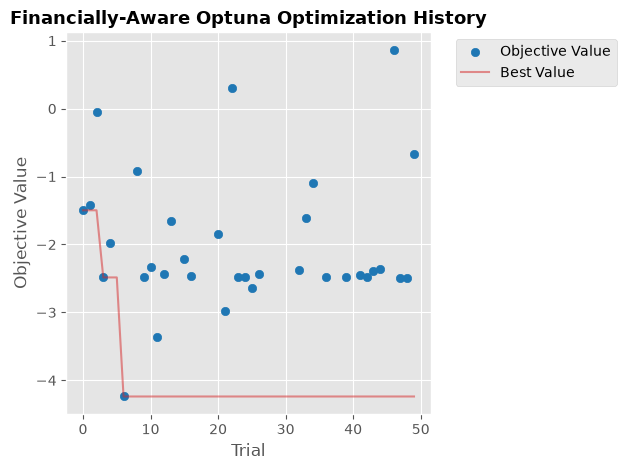

C:\Users\User\AppData\Local\Temp\ipykernel_24208\3991528456.py:12: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  opt_vis.plot_param_importances(study)


<Figure size 800x400 with 0 Axes>

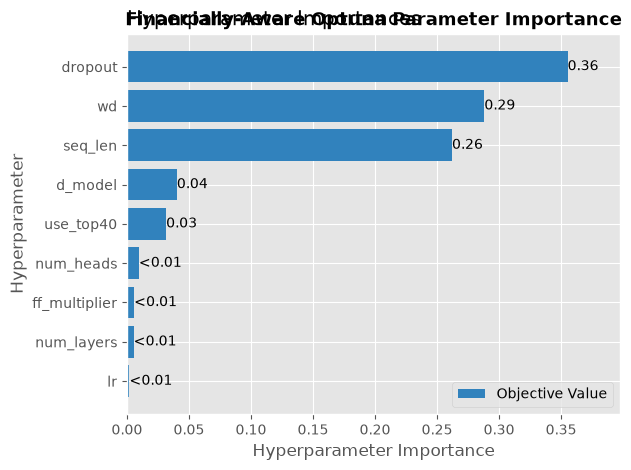

C:\Users\User\AppData\Local\Temp\ipykernel_24208\3991528456.py:21: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  opt_vis.plot_parallel_coordinate(study)


<Figure size 1200x600 with 0 Axes>

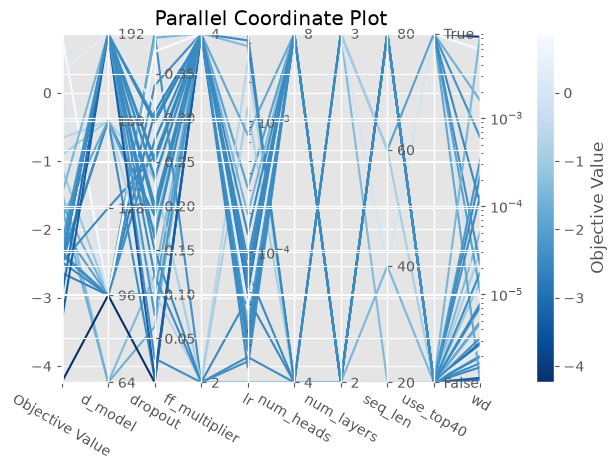

Optuna financial plots generated and saved to experiments/


In [9]:
# Plot optimization history
ax = opt_vis.plot_optimization_history(study)
fig = ax.figure
fig.set_size_inches(8, 4)
plt.title("Financially-Aware Optuna Optimization History", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig("experiments/optuna_history_financial.png", dpi=300)
plt.close(fig)

# Plot parameter importances
ax = opt_vis.plot_param_importances(study)
fig = ax.figure
fig.set_size_inches(8, 4)
plt.title("Financially-Aware Optuna Parameter Importance", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig("experiments/optuna_importance_financial.png", dpi=300)
plt.close(fig)

# Plot parallel coordinates
ax = opt_vis.plot_parallel_coordinate(study)
fig = ax.figure
fig.set_size_inches(12, 6)
plt.tight_layout()
fig.savefig("experiments/optuna_parallel_financial.png", dpi=300)
plt.close(fig)

print("Optuna financial plots generated and saved to experiments/")

In [10]:
print("\n--- Retraining the final model using best configuration ---")
best_params = study.best_trial.params
best_seq_len = best_params["seq_len"]
best_use_top40 = best_params["use_top40"]

# Features configuration
best_features = top_40_features if best_use_top40 else all_features
best_group_indices = {
    group: [best_features.index(col) for col in cols if col in best_features]
    for group, cols in FEATURE_GROUPS.items()
}
best_group_indices = {g: idx for g, idx in best_group_indices.items() if len(idx) > 0}

# Split df_master into original train / val / test sets (70% / 15% / 15%)
n = len(df_master)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_master.iloc[:train_end]
df_val = df_master.iloc[train_end:val_end]
df_test = df_master.iloc[val_end:]

# Scale features based on train set
scaler = StandardScaler()
X_tr_raw = scaler.fit_transform(df_train[best_features].fillna(0))
X_va_raw = scaler.transform(df_val[best_features].fillna(0))
X_te_raw = scaler.transform(df_test[best_features].fillna(0))

y_tr_series = df_train["Future_Return"].fillna(0)
y_va_series = df_val["Future_Return"].fillna(0)
y_te_series = df_test["Future_Return"].fillna(0)

# Generate sequences dynamically using best_seq_len
X_tr_subset, y_tr_subset = create_sequences(X_tr_raw, y_tr_series, best_seq_len)
X_va_subset, y_va_subset = create_sequences(X_va_raw, y_va_series, best_seq_len)
X_te_subset, y_te_subset = create_sequences(X_te_raw, y_te_series, best_seq_len)

# Create loaders
train_loader = DataLoader(TensorDataset(X_tr_subset, y_tr_subset), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_va_subset, y_va_subset), batch_size=64, shuffle=False)

final_model = AdaptiveFinancialTransformer(
    input_dim=len(best_features), feature_groups=best_group_indices, seq_len=best_seq_len,
    d_model=best_params["d_model"], num_heads=best_params["num_heads"],
    ff_dim=best_params["ff_multiplier"] * best_params["d_model"],
    num_layers=best_params["num_layers"], dropout=best_params["dropout"]
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(final_model.parameters(), lr=best_params["lr"], weight_decay=best_params["wd"], betas=(0.9, 0.95))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

# Train for 35 epochs
for epoch in range(35):
    final_model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds, _, _, _ = final_model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        optimizer.step()
        
    final_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds, _, _, _ = final_model(X_batch)
            val_loss += criterion(preds, y_batch).item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu() for k, v in final_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= 8:
        break

final_model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})

# Final Test evaluation
final_model.eval()
with torch.no_grad():
    test_preds, _, _, _ = final_model(X_te_subset.to(DEVICE))
    test_preds = test_preds.cpu().numpy()

y_te = y_te_subset.numpy()
opt_mae = mean_absolute_error(y_te, test_preds)
opt_r2 = r2_score(y_te, test_preds)
opt_dir_acc = np.mean(np.sign(y_te) == np.sign(test_preds))

# Calculate final test Sharpe
test_signal = np.sign(test_preds)
test_signal[np.abs(test_preds) < 1e-6] = 0.0
test_returns = test_signal * y_te
opt_sharpe = (np.mean(test_returns) / (np.std(test_returns) + 1e-9)) * np.sqrt(252 / 5)

print("\n================ FINAL OPTIMIZED TEST METRICS ================")
print(f"Optimized MAE: {opt_mae:.6f} | R2: {opt_r2:.6f} | Dir Acc: {opt_dir_acc:.4f} | Sharpe: {opt_sharpe:.4f}")

# Save best config to json file
with open("experiments/best_hyperparams_financial.json", "w") as f:
    json.dump(best_params, f, indent=4)

# Save study df to csv
study.trials_dataframe().to_csv("experiments/optuna_trials_financial.csv", index=False)


--- Retraining the final model using best configuration ---

================ FINAL OPTIMIZED TEST METRICS ================
Optimized MAE: 0.029788 | R2: 0.032198 | Dir Acc: 0.5866 | Sharpe: 1.1653


In [11]:
import os
import time

# Evaluate on test set
final_model.eval()
with torch.no_grad():
    test_preds, _, _, _ = final_model(X_te_subset.to(DEVICE))
    test_preds = test_preds.cpu().numpy()

y_te = y_te_subset.numpy()

# 1. Regression Metrics
opt_mae = mean_absolute_error(y_te, test_preds)
opt_rmse = np.sqrt(np.mean((y_te - test_preds) ** 2))
opt_r2 = r2_score(y_te, test_preds)

# 2. Trading Metrics
predicted_direction = np.sign(test_preds)
predicted_direction[np.abs(test_preds) < 1e-6] = 0.0
directional_accuracy = np.mean(np.sign(y_te) == predicted_direction)

strategy_returns = predicted_direction * y_te
mean_ret = np.mean(strategy_returns)
std_ret = np.std(strategy_returns) + 1e-9
opt_sharpe = (mean_ret / std_ret) * np.sqrt(252 / 5)

non_overlapping_returns = strategy_returns[::5]
cumulative_return = np.cumprod(1 + non_overlapping_returns)[-1] - 1

cum_series = np.cumprod(1 + non_overlapping_returns)
running_max = np.maximum.accumulate(cum_series)
drawdown = (cum_series - running_max) / (running_max + 1e-8)
max_drawdown = drawdown.min()

# 3. Model Parameters Count
param_count = sum(p.numel() for p in final_model.parameters() if p.requires_grad)

# Metadata configuration for Notebook 12.1 (Financial)
model_name = "Optimized AFT (Financial)"
notes = "Optuna financially-aware composite score optimization"
experiment_name = "Hyperparameter Optimization"

# Let elapsed_time be the retraining duration in seconds (computed during retraining)
if 'elapsed_time' not in locals():
    elapsed_time = 0.0 

# Define rows matching existing CSV schema exactly
baseline_row = f"{model_name},{opt_mae:.16f},{opt_rmse:.16f},{opt_r2:.16f}\n"
trading_row = f"{model_name},{directional_accuracy:.16f},{directional_accuracy:.16f},{opt_sharpe:.16f},{cumulative_return:.16f},{max_drawdown:.16f}\n"
log_row = f"{experiment_name},{model_name},{param_count},{elapsed_time:.2f},35.0,{opt_mae:.16f},{opt_rmse:.16f},{opt_r2:.16f},{directional_accuracy:.16f},{directional_accuracy:.16f},{opt_sharpe:.16f},{cumulative_return:.16f},{max_drawdown:.16f},{notes}\n"

# Safe append function
def append_row(filepath, row):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    if os.path.exists(filepath):
        with open(filepath, "r", encoding="utf-8") as f:
            content = f.read()
        if content and not content.endswith("\n"):
            row = "\n" + row
    with open(filepath, "a", encoding="utf-8") as f:
        f.write(row)

# Save to experiments/
append_row("experiments/baseline_results.csv", baseline_row)
append_row("experiments/trading_results.csv", trading_row)
append_row("experiments/experiment_log.csv", log_row)

print("Saved Optimized AFT (Financial) results to experiments CSV files successfully.")


Saved Optimized AFT (Financial) results to experiments CSV files successfully.
